# Phase 2 - Hierarchical Clustering

## Name: AYUSH KUMAR YADAV
## Registration Number: 23BDS0333
## Dataset: Lithium-Ion Battery Materials

### Objective

The objective of this notebook is to apply hierarchical clustering to the
Lithium-Ion Battery Materials dataset.

The numerical material properties are standardized before clustering.
Different hierarchical linkage methods, including Single, Complete,
Average, and Ward linkage, are compared.

Dendrograms and Silhouette Scores are used to evaluate the clustering
structure. The resulting clusters are analyzed using cluster sizes,
cluster profiles, and two-dimensional and three-dimensional visualizations.

HIERARCHICAL CLUSTERING

Dataset Shape:
(339, 30)

Variables used for clustering:
['formation_energy_ev', 'e_above_hull_ev', 'band_gap_ev', 'nsites', 'density_gm_cc', 'volume']

Number of observations used:
338

Standardization completed.

Linkage methods:
['single', 'complete', 'average', 'ward']


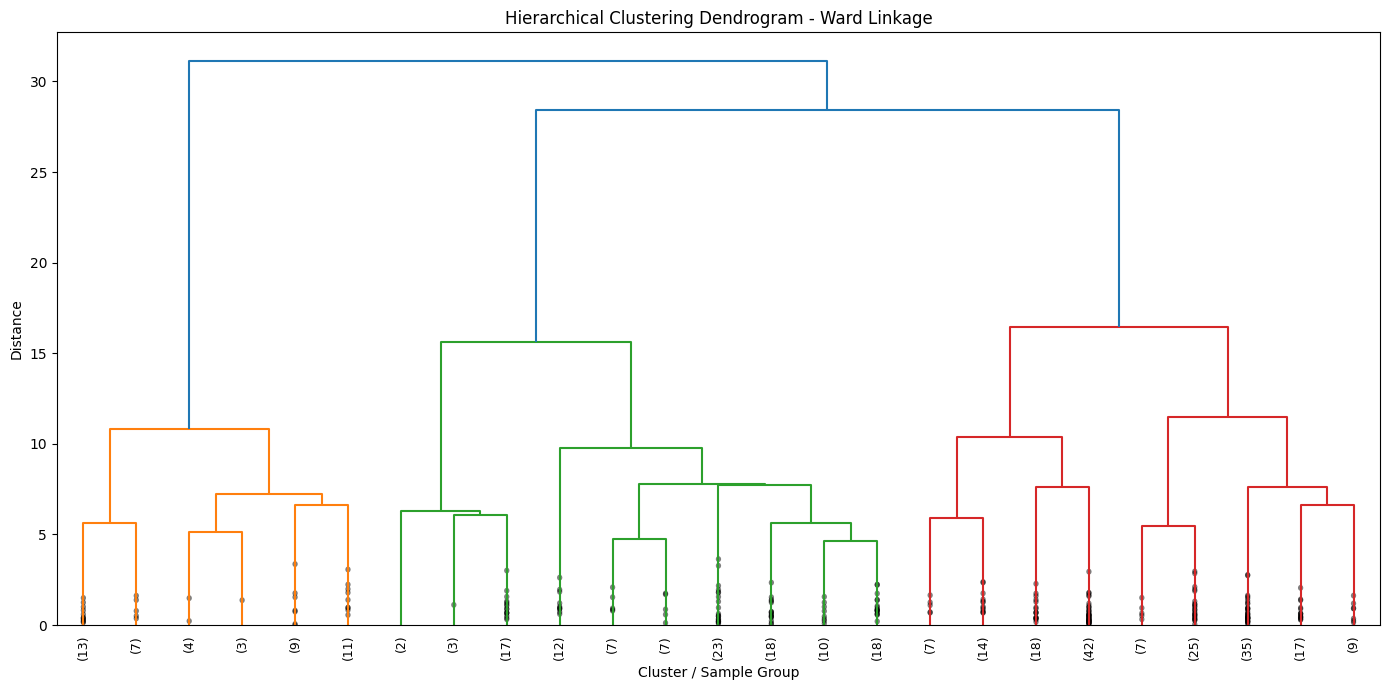

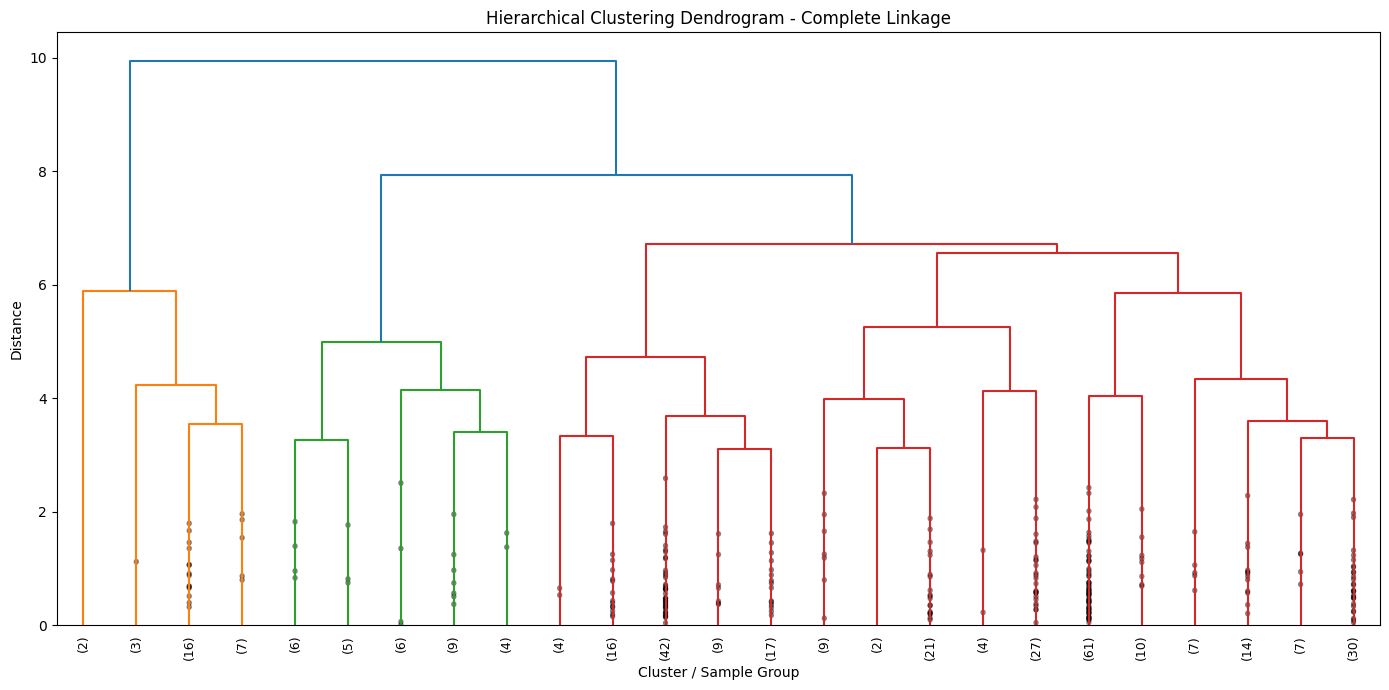


COMPARING LINKAGE METHODS


,Linkage Method,Clusters,Silhouette Score
0,single,3,0.373599
1,complete,3,0.249482
2,average,3,0.313093
3,ward,3,0.269094


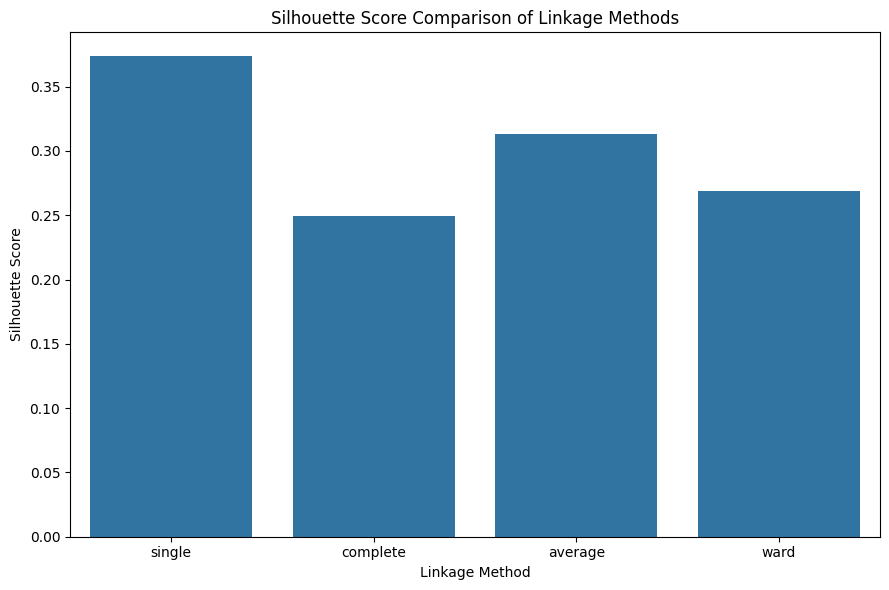


Best Linkage Method:
single

Silhouette Score:
0.37359916285119615

CLUSTER COUNT ANALYSIS


,Number of Clusters,Silhouette Score
0,2,0.497353
1,3,0.373599
2,4,0.335318
3,5,0.277991
4,6,0.270045


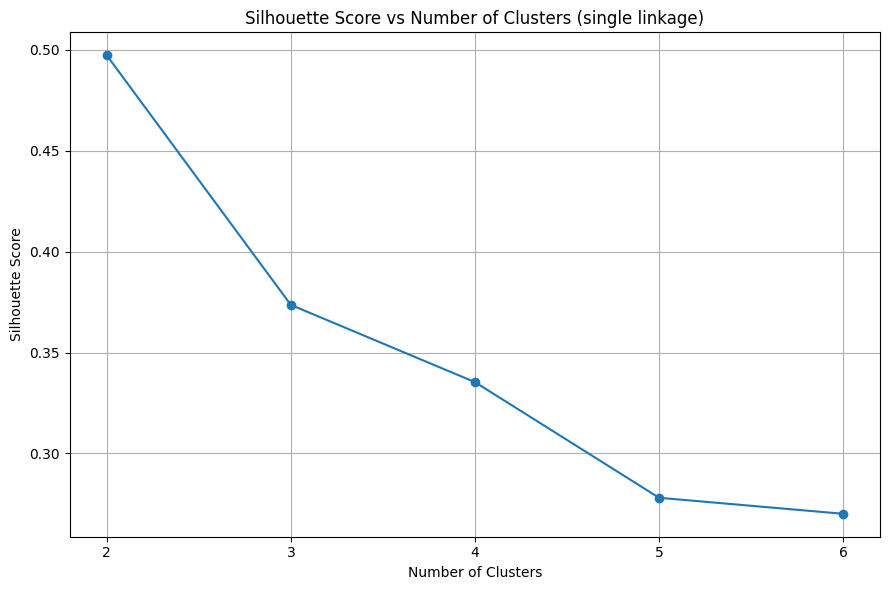


Optimal Number of Clusters:
2

Optimal Silhouette Score:
0.4973528513427078

Final hierarchical clustering completed.

CLUSTER SIZES


,Number of Materials
Cluster,
0,337
1,1



CLUSTER PROFILE


,formation_energy_ev,e_above_hull_ev,band_gap_ev,nsites,density_gm_cc,volume
Cluster,,,,,,
0,-2.6179,0.0578,2.0842,38.8012,2.9826,467.2219
1,-2.0120,0.1900,0.7170,22.0000,3.9270,216.3380


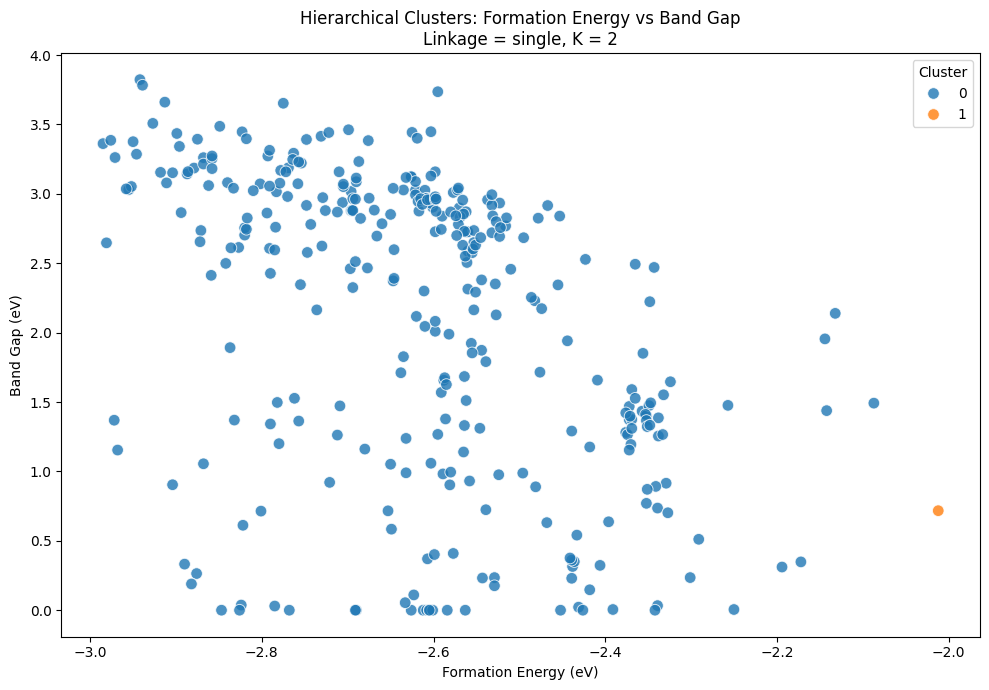

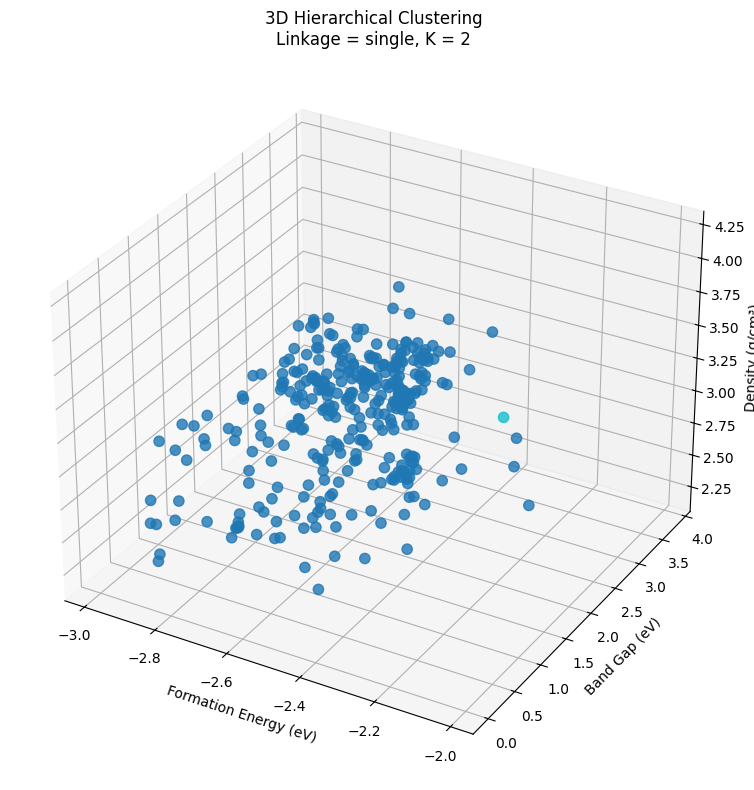

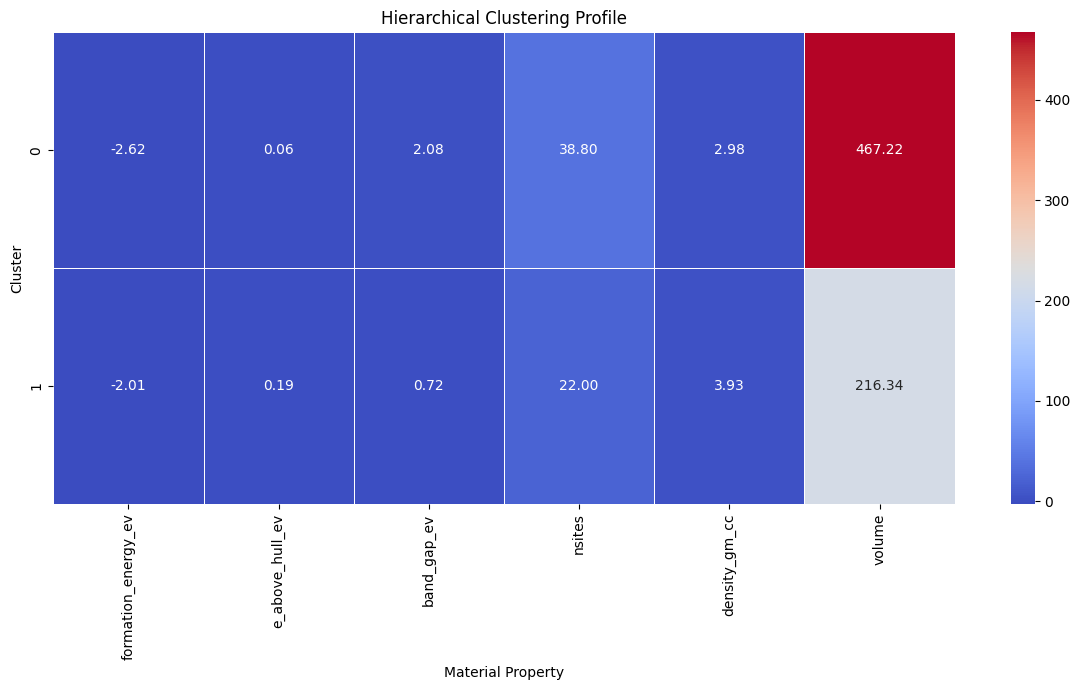


FINAL HIERARCHICAL CLUSTERING RESULTS
Best Linkage Method: single
Optimal Number of Clusters: 2
Final Silhouette Score: 0.4973528513427078

Clustered dataset saved as:
lithium_ion_hierarchical_clustered.csv

HIERARCHICAL CLUSTERING COMPLETED


In [1]:
# ============================================================
# PHASE 2 - HIERARCHICAL CLUSTERING
# Name        : AYUSH KUMAR YADAV
# Registration: 23BDS0333
# Dataset     : Lithium-Ion Battery Materials
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

file_path = "lithium_ion_transformed.csv"

df = pd.read_csv(file_path)

print("=" * 75)
print("HIERARCHICAL CLUSTERING")
print("=" * 75)

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------------------
# 2. SELECT CLUSTERING VARIABLES
# ------------------------------------------------------------

clustering_columns = [
    "formation_energy_ev",
    "e_above_hull_ev",
    "band_gap_ev",
    "nsites",
    "density_gm_cc",
    "volume"
]

clustering_columns = [
    column for column in clustering_columns
    if column in df.columns
]

print("\nVariables used for clustering:")
print(clustering_columns)

# ------------------------------------------------------------
# 3. PREPARE DATA
# ------------------------------------------------------------

clustering_data = df[
    clustering_columns
].dropna()

print("\nNumber of observations used:")
print(len(clustering_data))

# ------------------------------------------------------------
# 4. STANDARDIZE DATA
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    clustering_data
)

print("\nStandardization completed.")

# ------------------------------------------------------------
# 5. HIERARCHICAL LINKAGE METHODS
# ------------------------------------------------------------

linkage_methods = [
    "single",
    "complete",
    "average",
    "ward"
]

print("\nLinkage methods:")
print(linkage_methods)

# ============================================================
# VISUALIZATION 1
# WARD LINKAGE DENDROGRAM
# ============================================================

plt.figure(figsize=(14, 7))

ward_linkage = linkage(
    X_scaled,
    method="ward"
)

dendrogram(
    ward_linkage,
    truncate_mode="lastp",
    p=25,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)

plt.title(
    "Hierarchical Clustering Dendrogram - Ward Linkage"
)

plt.xlabel("Cluster / Sample Group")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2
# COMPLETE LINKAGE DENDROGRAM
# ============================================================

plt.figure(figsize=(14, 7))

complete_linkage = linkage(
    X_scaled,
    method="complete"
)

dendrogram(
    complete_linkage,
    truncate_mode="lastp",
    p=25,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True
)

plt.title(
    "Hierarchical Clustering Dendrogram - Complete Linkage"
)

plt.xlabel("Cluster / Sample Group")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. COMPARE LINKAGE METHODS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("COMPARING LINKAGE METHODS")
print("=" * 75)

linkage_results = []

comparison_k = 3

for method in linkage_methods:

    model = AgglomerativeClustering(
        n_clusters=comparison_k,
        linkage=method
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    linkage_results.append({
        "Linkage Method": method,
        "Clusters": comparison_k,
        "Silhouette Score": score
    })

linkage_results_df = pd.DataFrame(
    linkage_results
)

display(linkage_results_df)

# ============================================================
# VISUALIZATION 3
# LINKAGE METHOD COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

sns.barplot(
    data=linkage_results_df,
    x="Linkage Method",
    y="Silhouette Score"
)

plt.title(
    "Silhouette Score Comparison of Linkage Methods"
)

plt.xlabel("Linkage Method")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. SELECT BEST LINKAGE METHOD
# ------------------------------------------------------------

best_linkage_row = linkage_results_df.loc[
    linkage_results_df["Silhouette Score"].idxmax()
]

best_linkage = best_linkage_row[
    "Linkage Method"
]

best_linkage_score = best_linkage_row[
    "Silhouette Score"
]

print("\nBest Linkage Method:")
print(best_linkage)

print("\nSilhouette Score:")
print(best_linkage_score)

# ------------------------------------------------------------
# 8. TEST DIFFERENT NUMBERS OF CLUSTERS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLUSTER COUNT ANALYSIS")
print("=" * 75)

cluster_range = range(2, 7)

cluster_scores = []

for k in cluster_range:

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage=best_linkage
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    cluster_scores.append({
        "Number of Clusters": k,
        "Silhouette Score": score
    })

cluster_scores_df = pd.DataFrame(
    cluster_scores
)

display(cluster_scores_df)

# ============================================================
# VISUALIZATION 4
# SILHOUETTE SCORE VS CLUSTER COUNT
# ============================================================

plt.figure(figsize=(9, 6))

plt.plot(
    cluster_scores_df["Number of Clusters"],
    cluster_scores_df["Silhouette Score"],
    marker="o"
)

plt.title(
    f"Silhouette Score vs Number of Clusters ({best_linkage} linkage)"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(list(cluster_range))
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. SELECT OPTIMAL NUMBER OF CLUSTERS
# ------------------------------------------------------------

best_cluster_row = cluster_scores_df.loc[
    cluster_scores_df["Silhouette Score"].idxmax()
]

best_k = int(
    best_cluster_row["Number of Clusters"]
)

best_k_score = best_cluster_row[
    "Silhouette Score"
]

print("\nOptimal Number of Clusters:")
print(best_k)

print("\nOptimal Silhouette Score:")
print(best_k_score)

# ------------------------------------------------------------
# 10. FINAL HIERARCHICAL CLUSTERING MODEL
# ------------------------------------------------------------

final_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage=best_linkage
)

final_labels = final_model.fit_predict(
    X_scaled
)

# Add cluster labels to corresponding rows
clustered_df = df.loc[
    clustering_data.index
].copy()

clustered_df["Cluster"] = final_labels

print("\nFinal hierarchical clustering completed.")

# ------------------------------------------------------------
# 11. CLUSTER SIZES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLUSTER SIZES")
print("=" * 75)

cluster_sizes = (
    clustered_df["Cluster"]
    .value_counts()
    .sort_index()
)

display(
    cluster_sizes.to_frame(
        "Number of Materials"
    )
)

# ------------------------------------------------------------
# 12. CLUSTER PROFILE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLUSTER PROFILE")
print("=" * 75)

cluster_profile = (
    clustered_df
    .groupby("Cluster")[clustering_columns]
    .mean()
    .round(4)
)

display(cluster_profile)

# ============================================================
# VISUALIZATION 5
# 2D HIERARCHICAL CLUSTERING
# ============================================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=clustered_df,
    x="formation_energy_ev",
    y="band_gap_ev",
    hue="Cluster",
    palette="tab10",
    s=70,
    alpha=0.8
)

plt.title(
    f"Hierarchical Clusters: Formation Energy vs Band Gap\n"
    f"Linkage = {best_linkage}, K = {best_k}"
)

plt.xlabel("Formation Energy (eV)")
plt.ylabel("Band Gap (eV)")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 6
# 3D HIERARCHICAL CLUSTERING
# ============================================================

fig = plt.figure(figsize=(11, 8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    clustered_df["formation_energy_ev"],
    clustered_df["band_gap_ev"],
    clustered_df["density_gm_cc"],
    c=clustered_df["Cluster"],
    cmap="tab10",
    s=55,
    alpha=0.8
)

ax.set_title(
    f"3D Hierarchical Clustering\n"
    f"Linkage = {best_linkage}, K = {best_k}"
)

ax.set_xlabel("Formation Energy (eV)")
ax.set_ylabel("Band Gap (eV)")
ax.set_zlabel("Density (g/cm³)")

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 7
# CLUSTER PROFILE HEATMAP
# ============================================================

plt.figure(figsize=(12, 7))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Hierarchical Clustering Profile"
)

plt.xlabel("Material Property")
plt.ylabel("Cluster")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. FINAL SILHOUETTE SCORE
# ------------------------------------------------------------

final_silhouette = silhouette_score(
    X_scaled,
    final_labels
)

print("\n" + "=" * 75)
print("FINAL HIERARCHICAL CLUSTERING RESULTS")
print("=" * 75)

print("Best Linkage Method:", best_linkage)
print("Optimal Number of Clusters:", best_k)
print("Final Silhouette Score:", final_silhouette)

# ------------------------------------------------------------
# 14. SAVE CLUSTERED DATASET
# ------------------------------------------------------------

output_file = (
    "lithium_ion_hierarchical_clustered.csv"
)

clustered_df.to_csv(
    output_file,
    index=False
)

print("\nClustered dataset saved as:")
print(output_file)

print("\n" + "=" * 75)
print("HIERARCHICAL CLUSTERING COMPLETED")
print("=" * 75)

# Conclusion

Hierarchical clustering was successfully applied to the Lithium-Ion
Battery Materials dataset.

The numerical material properties were standardized before clustering.
Multiple linkage methods, including Single, Complete, Average, and Ward,
were compared using Silhouette Scores.

Dendrograms were generated to visualize the hierarchical structure of the
data. The linkage method and number of clusters producing the highest
Silhouette Score were selected for the final clustering model.

The resulting clusters were examined through cluster sizes, cluster
profiles, two-dimensional visualization, three-dimensional visualization,
and a cluster-profile heatmap.

The final hierarchical clustering dataset was saved as
`lithium_ion_hierarchical_clustered.csv`.

This completes the Phase 2 clustering analysis of the Lithium-Ion Battery
Materials dataset.